# Full Forecasting Pipeline

**Docker image**: `ml4t`

This notebook wires together all components from NB04–NB07 into the complete
**agent → aggregation → debate → supervisor** pipeline: the AIA Forecaster.
We build the `SupervisorAgent` and `AIAForecaster` classes inline, then run
the full pipeline on the chapter's two pinned, still-**unresolved** questions
(the recession question from NB06 and the rate-hike question from NB07).
Because the outcomes are not yet known, the pipeline produces probabilities
but does not score them. Brier and log-loss scoring against resolved
outcomes is the job of NB09.

**Learning Objectives**:
- Build the supervisor agent: disagreement detection, clarifying search, override
- Compose the four-phase pipeline into the `AIAForecaster` class
- Run the pipeline on multiple questions and inspect the full trace
- Track token usage across the complete pipeline

**Book Reference**: Chapter 24, Sections 24.7 (complete pipeline) and 24.8
(Production: persistence and replay)

**Prerequisites**: NB04 (research agent), NB05 (aggregation), NB07 (debate).

In [1]:
"""Full Forecasting Pipeline: agent-debate-supervisor end-to-end."""

import json
import time
import warnings
from datetime import date

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import polars as pl
from agent_fixtures import get_chapter_clear_question, get_chapter_contested_question
from agent_observability import (
    TRACES_DIR,
    RunTrace,
    show_agents,
    show_debate_transcript,
    show_supervisor,
    trace_llm,
)
from agent_pipeline import neyman_extremize
from agent_providers import ChatMessage, TokenUsage, create_llm_client
from agent_research import ResearchAgent, format_agent_summary, parse_json
from agent_schemas import (
    AgentForecastArtifact,
    ForecastQuestion,
    ForecastResult,
    SearchResult,
    SupervisorArtifact,
)
from agent_specialists import DebateAgent
from agent_tools import (
    SearchClient,
    ToolExecutor,
    create_search_client,
)
from IPython.display import Markdown, display

from utils.style import COLORS, add_message_title

In [2]:
# RUN_LIVE=False (the default) replays the pinned 2026-06-09 traces named below,
# one per question. It reloads each saved pipeline run and makes no API calls, so
# every table and trace matches the chapter. Set RUN_LIVE=True (with API keys) to
# forecast current questions live; that path produces different numbers.
RUN_LIVE = False
PINNED_TRACES = [
    "08_forecasting_pipeline_20260609T141954Z_ef5bca7b95bd.json",  # recession (clear)
    "08_forecasting_pipeline_20260609T142158Z_24e083e7fe54.json",  # rate hike (contested)
]

LLM_PROVIDER = ""  # empty = auto-detect; "mock" for CI (live path only)
N_AGENTS = 3
DEBATE_ROUNDS = 3
MAX_STEPS = 5
MAX_SEARCH_RESULTS = 5

## Supervisor Prompts

The supervisor operates in two phases:
1. **Identify disagreements** among agents and propose clarifying searches
2. **Finalize** with updated probability, incorporating new evidence

These prompts are shown inline from the AIA Forecaster's production templates.

In [3]:
SUPERVISOR_DISAGREEMENTS_PROMPT = """\
You are the SUPERVISOR agent.

You receive M agent forecasts and rationales for the same question.
Your job is NOT to average them directly.

Step 1: Identify key disagreements, ambiguities, missing base rates, or claims that should be fact-checked.
Step 2: Propose up to {max_queries} clarifying search queries that would resolve these disagreements.

Output JSON only with:
{{"disagreements": ["..."], "queries": ["..."]}}

AGENT INPUTS:
{agent_summaries}"""

The finalize prompt receives the original question, agent panel, and bounded
follow-up evidence. It requests a probability, confidence label, and rationale.

In [4]:
SUPERVISOR_FINALIZE_PROMPT = """\
You are the SUPERVISOR agent.

Given:
1) The original question
2) The set of agent forecasts and rationales
3) Additional evidence from your follow-up searches

You must output:
1) Updated forecast p_yes in [0,1]
2) Confidence in whether your update direction is correct: "high" | "medium" | "low"
3) A short rationale

Output JSON only:
{{"p_yes": 0.0, "confidence": "high", "rationale": "..."}}

QUESTION:
{question}

AGENT INPUTS:
{agent_summaries}

SUPERVISOR SEARCH EVIDENCE:
{supervisor_evidence}"""

## Supervisor phase helpers

The supervisor's three phases (identify, search, finalize) factor
naturally into free functions. The class then becomes a thin shell that
owns the LLM + search clients and threads them through the helpers.

In [5]:
def _supervisor_identify_disagreements(
    llm,
    agent_summaries: str,
    max_queries: int,
) -> tuple[list[str], list[str], TokenUsage]:
    """Phase 1: LLM call asking for disagreements and clarifying queries."""
    prompt = SUPERVISOR_DISAGREEMENTS_PROMPT.format(
        max_queries=max_queries, agent_summaries=agent_summaries
    )
    raw, tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=prompt)], json_mode=True
    )
    parsed = parse_json(raw)
    disagreements = [str(x) for x in parsed.get("disagreements", [])][:20]
    queries = [str(x) for x in parsed.get("queries", [])][:max_queries]
    return disagreements, queries, tokens

The search phase executes only the supervisor's bounded query list and
applies the question's point-in-time cutoff to every request.

In [6]:
def _supervisor_run_searches(
    search,
    queries: list[str],
    max_search_results: int,
    cutoff_date: date | None,
) -> dict[str, list[SearchResult]]:
    """Phase 2: execute the clarifying-search queries via ToolExecutor."""
    if search is None:
        return {}
    executor = ToolExecutor(search=search)
    return {
        q: executor.execute_search(q, max_results=max_search_results, cutoff_date=cutoff_date)
        for q in queries
    }

Search results become a compact evidence block for the final model call.
Dates and source URLs remain visible for audit.

In [7]:
def _format_supervisor_evidence(sr: dict[str, list[SearchResult]]) -> str:
    """Render the search-result dict into the supervisor-finalize prompt's evidence block."""
    lines: list[str] = []
    for q, results in sr.items():
        lines.append(f"QUERY: {q}")
        for i, r in enumerate(results, start=1):
            lines.append(f"{i}. {r.title}")
            if r.url:
                lines.append(f"   URL: {r.url}")
            if r.snippet:
                lines.append(f"   {r.snippet}")
            if r.published:
                lines.append(f"   Published: {r.published}")
        lines.append("")
    return "\n".join(lines) if lines else "No additional search evidence."

The final phase parses and clamps the supervisor probability. Invalid
confidence labels fall back to `medium` instead of triggering an override.

In [8]:
def _supervisor_finalize(
    llm,
    question: str,
    agent_summaries: str,
    search_results: dict[str, list[SearchResult]],
) -> tuple[float | None, str | None, str | None, TokenUsage]:
    """Phase 3: LLM call asking for final p_yes / confidence / rationale."""
    evidence_text = _format_supervisor_evidence(search_results)
    prompt = SUPERVISOR_FINALIZE_PROMPT.format(
        question=question,
        agent_summaries=agent_summaries,
        supervisor_evidence=evidence_text,
    )
    raw, tokens = llm.complete_with_usage(
        [ChatMessage(role="user", content=prompt)], json_mode=True
    )
    parsed = parse_json(raw)
    p_yes_raw = parsed.get("p_yes")
    confidence = parsed.get("confidence")
    rationale = parsed.get("rationale")

    if confidence is not None:
        conf_str = str(confidence).lower()
        if conf_str not in ("high", "medium", "low"):
            conf_str = "medium"
        confidence = conf_str

    p_yes = float(p_yes_raw) if p_yes_raw is not None else None
    if p_yes is not None:
        p_yes = max(0.0, min(1.0, p_yes))
    return p_yes, confidence, rationale, tokens

The driver combines the three phases and returns both the artifact and its
token count.

In [9]:
def _run_supervisor(
    supervisor,
    question: str,
    agent_summaries: str,
    cutoff_date: date | None,
) -> tuple[SupervisorArtifact, TokenUsage]:
    """Run identify, search, and finalize in sequence."""
    disagreements, queries, identify_tokens = _supervisor_identify_disagreements(
        supervisor.llm, agent_summaries, supervisor.max_queries
    )
    search_results = _supervisor_run_searches(
        supervisor.search, queries, supervisor.max_search_results, cutoff_date
    )
    p_yes, confidence, rationale, finalize_tokens = _supervisor_finalize(
        supervisor.llm, question, agent_summaries, search_results
    )
    tokens = identify_tokens + finalize_tokens
    artifact = SupervisorArtifact(
        disagreements=disagreements,
        queries=queries,
        search_results=search_results,
        p_yes=p_yes,
        confidence=confidence,
        rationale=str(rationale) if rationale is not None else None,
        token_usage=tokens,
    )
    return artifact, tokens

## The SupervisorAgent Class

Three phases: (1) identify disagreements, (2) run clarifying searches,
(3) finalize with evidence. The supervisor only overrides the ensemble
when its confidence is "high", preserving agent diversity by default.

In [10]:
class SupervisorAgent:
    """Supervisor that reconciles agent ensemble via clarifying searches."""

    def __init__(
        self,
        llm,
        search: SearchClient | None = None,
        max_queries: int = 3,
        max_search_results: int = 5,
    ) -> None:
        self.llm = llm
        self.search = search
        self.max_queries = max_queries
        self.max_search_results = max_search_results
        self.token_usage = TokenUsage()

    def run(
        self,
        question: str,
        agent_summaries: str,
        cutoff_date: date | None = None,
    ) -> SupervisorArtifact:
        """Run supervisor reconciliation. Returns SupervisorArtifact."""
        artifact, self.token_usage = _run_supervisor(self, question, agent_summaries, cutoff_date)
        return artifact

## Pipeline helpers

The pipeline reuses the debate implementation from NB07 through
`agent_specialists.DebateAgent`. The local helpers run the research ensemble
and apply the supervisor's confidence-gated override.

In [11]:
def _run_research_agents(
    llm,
    search,
    question: ForecastQuestion,
    n_agents: int,
    max_steps: int,
) -> list[AgentForecastArtifact]:
    """Phase 1: run N identical ResearchAgents and collect their artifacts."""
    artifacts: list[AgentForecastArtifact] = []
    for i in range(n_agents):
        agent = ResearchAgent(llm=llm, search=search, agent_id=f"agent_{i}", max_steps=max_steps)
        artifacts.append(agent.run(question, market_price=question.current_market_price))
    return artifacts

The final blend lets high-confidence supervisors override the debate.
Medium confidence receives a 40% weight; low confidence leaves the
post-debate probability unchanged.

In [12]:
def _blend_final_probability(
    post_debate: float,
    supervisor_artifact: SupervisorArtifact,
) -> tuple[float, float]:
    """Phase 4 → final: confidence-gated supervisor override. Returns (final_p, final_confidence)."""
    final_p = post_debate
    final_confidence = 0.5
    if supervisor_artifact.p_yes is not None and supervisor_artifact.confidence == "high":
        final_p = supervisor_artifact.p_yes
        final_confidence = 0.8
    elif supervisor_artifact.confidence == "medium":
        if supervisor_artifact.p_yes is not None:
            final_p = 0.6 * post_debate + 0.4 * supervisor_artifact.p_yes
        final_confidence = 0.6
    return max(0.01, min(0.99, final_p)), final_confidence

The execution helper composes the four phases and records their artifacts.
Keeping orchestration outside the class leaves the reader-facing class as a
small configuration object.

In [13]:
def _forecast_one(forecaster, question: ForecastQuestion) -> ForecastResult:
    started = time.time()
    cutoff = date.fromisoformat(question.cutoff_date) if question.cutoff_date else None
    agents = _run_research_agents(
        forecaster.llm, forecaster.search, question, forecaster.n_agents, forecaster.max_steps
    )
    summaries = "\n\n---\n\n".join(format_agent_summary(agent) for agent in agents)
    aggregation = neyman_extremize(
        [agent.p_yes for agent in agents], base=0.5, correlation=forecaster.correlation
    )
    aggregate_p = aggregation.extremized_probability or aggregation.raw_probability
    debate = DebateAgent(
        llm=forecaster.llm,
        max_rounds=forecaster.debate_rounds,
        consensus_threshold=forecaster.consensus_threshold,
    ).run(question.question, summaries, aggregate_p)
    midpoint = (
        (debate.bull_final_probability + debate.bear_final_probability) / 2
        if debate.bull_final_probability is not None
        else aggregate_p
    )
    supervisor = SupervisorAgent(llm=forecaster.llm, search=forecaster.search).run(
        question.question, summaries, cutoff_date=cutoff
    )
    final_p, confidence = _blend_final_probability(0.7 * aggregate_p + 0.3 * midpoint, supervisor)
    tokens = sum((agent.token_usage for agent in agents), start=TokenUsage())
    tokens = tokens + debate.token_usage + supervisor.token_usage
    return ForecastResult(
        question=question,
        agents=agents,
        aggregation=aggregation,
        debate=debate,
        supervisor=supervisor,
        final_probability=round(final_p, 4),
        final_confidence=round(confidence, 3),
        total_token_usage=tokens,
        duration_seconds=round(time.time() - started, 2),
    )

## The AIAForecaster Class

The complete four-phase pipeline:
1. **Research agents**: N parallel agents produce forecasts
2. **Aggregation**: Neyman extremization combines agent probabilities
3. **Debate**: Bull/bear stress-test the aggregate
4. **Supervisor**: Reconcile with clarifying searches, confidence-gated override

In [14]:
class AIAForecaster:
    """Complete AIA Forecaster pipeline: agents → aggregate → debate → supervisor."""

    def __init__(
        self,
        llm,
        search: SearchClient | None = None,
        n_agents: int = 3,
        max_steps: int = 5,
        debate_rounds: int = 3,
        consensus_threshold: float = 0.05,
        correlation: float = 0.3,
    ) -> None:
        self.llm = llm
        self.search = search
        self.n_agents = n_agents
        self.max_steps = max_steps
        self.debate_rounds = debate_rounds
        self.consensus_threshold = consensus_threshold
        self.correlation = correlation

    def forecast(self, question: ForecastQuestion) -> ForecastResult:
        """Run the full pipeline on a single question."""
        return _forecast_one(self, question)

## Forecast Questions

We run the full pipeline on the chapter's two pinned questions: the
one-directional `CHAPTER_CLEAR_QUESTION` (recession), where the agents agreed
closely in NB06, and the contested `CHAPTER_CONTESTED_QUESTION` (rate hike),
where they spread out in NB07. Running both end-to-end shows how the aggregate,
debate, and supervisor stages behave on an easy question and a hard one. The
numbers are a dated point-in-time capture (2026-06-09). By default the notebook
*replays* the pinned trace for each question (`RUN_LIVE = False`): it reloads
the saved pipeline runs and makes no API calls, so the results are stable. Set
`RUN_LIVE = True` (with `ANTHROPIC_API_KEY` and `TAVILY_API_KEY`) to forecast
current questions live, which is not reproducible.

In [15]:
questions = [get_chapter_clear_question(), get_chapter_contested_question()]

print(f"Forecasting {len(questions)} questions:")
for q in questions:
    market = f"{q.current_market_price:.0%}" if q.current_market_price is not None else "?"
    print(f"  • {q.question}")
    if q.resolution_date:
        print(f"    Resolves: {q.resolution_date} | Market: {market}")
    else:
        print(f"    Market: {market}")

Forecasting 2 questions:
  • Will the US enter a recession by the end of 2026?
    Resolves: 2027-01-31 | Market: 18%
  • Will the Federal Reserve hike rates in 2026?
    Resolves: 2026-12-09 | Market: 55%


## Running the Pipeline

Live execution is isolated in one helper. The publication path below never
calls it while `RUN_LIVE` remains false.

In [16]:
def _run_live_questions(questions_to_run: list[ForecastQuestion]) -> tuple[list, list]:
    """Run and persist fresh provider-backed forecasts."""
    llm = create_llm_client(LLM_PROVIDER)
    search = create_search_client(LLM_PROVIDER)
    live_results, live_traces = [], []
    for q in questions_to_run:
        tracer = trace_llm(llm, label="pipeline")
        forecaster = AIAForecaster(
            llm=tracer,
            search=search,
            n_agents=N_AGENTS,
            max_steps=MAX_STEPS,
            debate_rounds=DEBATE_ROUNDS,
            correlation=0.3,
        )
        result = forecaster.forecast(q)
        run = RunTrace.from_result(
            result,
            notebook="08_forecasting_pipeline",
            provider=llm.model_name,
            params={
                "n_agents": N_AGENTS,
                "max_steps": MAX_STEPS,
                "debate_rounds": DEBATE_ROUNDS,
                "correlation": 0.3,
            },
            llm_calls=tracer.calls,
            notes="Full AIA pipeline: research, aggregate, debate, supervisor.",
        )
        path = run.save()
        print(
            f"  ✓ {q.question[:50]}... → {result.final_probability:.2f} "
            f"({result.duration_seconds:.1f}s) | {len(run.llm_calls)} calls → {path.name}"
        )
        live_results.append(result)
        live_traces.append(run)
    return live_results, live_traces

Replay loads only the two committed trace names. No provider client or search
client is created on this path.

In [17]:
def _load_pinned_questions() -> tuple[list, list]:
    """Rehydrate the two committed pipeline traces."""
    replay_results, replay_traces = [], []
    for pinned_name in PINNED_TRACES:
        run = RunTrace.load(TRACES_DIR / pinned_name)
        result = run.forecast_result()
        print(
            f"  ✓ {result.question.question[:50]}... → {result.final_probability:.2f} "
            f"(replay) | {len(run.llm_calls)} calls from {pinned_name}"
        )
        replay_results.append(result)
        replay_traces.append(run)
    return replay_results, replay_traces

In [18]:
if RUN_LIVE:
    results, run_traces = _run_live_questions(questions)
else:
    results, run_traces = _load_pinned_questions()

  ✓ Will the US enter a recession by the end of 2026?... → 0.17 (replay) | 21 calls from 08_forecasting_pipeline_20260609T141954Z_ef5bca7b95bd.json
  ✓ Will the Federal Reserve hike rates in 2026?... → 0.27 (replay) | 20 calls from 08_forecasting_pipeline_20260609T142158Z_24e083e7fe54.json


## Results Summary

In [19]:
grand_total = TokenUsage()
for r in results:
    grand_total = grand_total + r.total_token_usage

summary_df = pl.DataFrame(
    [
        {
            "question": r.question.question[:80],
            "final": round(r.final_probability, 3),
            "market": (
                round(r.question.current_market_price, 3)
                if r.question.current_market_price is not None
                else None
            ),
            "confidence": round(r.final_confidence, 2),
            "duration_s": (
                round(r.duration_seconds, 1) if r.duration_seconds is not None else None
            ),
        }
        for r in results
    ]
)
print(f"Total tokens across {len(results)} questions: {grand_total.total_tokens:,}\n")
summary_df

Total tokens across 2 questions: 164,463



question,final,market,confidence,duration_s
str,f64,f64,f64,null
"""Will the US enter a recession …",0.175,0.175,0.6,null
"""Will the Federal Reserve hike …",0.274,0.545,0.6,null


## Detailed Pipeline Trace: Question 1

The full, untruncated trace for the first question, phase by phase, rendered
by the `agent_observability` helpers used throughout the arc. Together they
show exactly how each stage moves the probability: the research agents'
timelines (every query, document, and rationale), the debate transcript (both
sides' complete arguments and cited evidence), and the supervisor's
reconciliation (the disagreements it flagged, the clarifying searches it ran,
and its final verdict). Everything here was also persisted to the JSON trace
saved above, so this readout can be reproduced from disk with `RunTrace.load`.

In [20]:
r = results[0]
display(
    {"text/plain": (f"Question: {r.question.question}\n\n{show_agents(r.agents)}")},
    raw=True,
)

Question: Will the US enter a recession by the end of 2026?

  AGENT_0  ·  p_yes=0.22  confidence=0.56  sentiment=bearish  evidence=high
  searches=4  sources=20  tokens=36,288
  Step 1 · SEARCH  "US economic indicators 2024 2025 GDP growth inflation unemployment Federal Reserve"
      1. [?] An Update to the Economic Outlook: 2023 to 2025
         https://www.cbo.gov/publication/59258
         Real GDP increases by 1.5 percent in 2024 and by 2.4 percent in 2025.
         That initial slowdown in economic growth drives up unemployment. The
      2. [?] Third Quarter 2025 Survey of Professional Forecasters
         https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/spf-q3-2025
         *   [Survey of Professional
         Forecasters](https://www.philadelphiafed.org/surveys-and-data/real-
         time-data-research/survey-of-professional-forecasters).
         [](https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-
         Data/survey-of-professional-

In [21]:
print("── Aggregation ──")
if r.aggregation:
    print(f"  method:     {r.aggregation.method}")
    print(f"  inputs:     {r.aggregation.input_probabilities}")
    print(f"  raw mean:   {r.aggregation.raw_probability:.2f}")
    print(f"  extremized: {r.aggregation.extremized_probability:.2f}")
    print(f"  d={r.aggregation.extremization_factor:.2f}, n_eff={r.aggregation.effective_n:.1f}")

── Aggregation ──
  method:     neyman
  inputs:     [0.22, 0.22, 0.22]
  raw mean:   0.22
  extremized: 0.12
  d=1.37, n_eff=1.9


In [22]:
if r.debate:
    print(show_debate_transcript(r.debate))

  DEBATE  ·  3 round(s)  ·  consensus=no  ·  tokens=6,523

  ── Round 1 ──  bull=0.45  bear=0.18  gap=0.27  consensus=no
  BULL (p=0.45):
    The probability of recession by 2026 is significantly underestimated.
    While current forecasts appear optimistic, multiple converging risk
    factors create a perfect storm scenario. The Federal Reserve's aggressive
    rate hiking cycle has created substantial lag effects that typically
    manifest 12-18 months later, meaning the full impact won't be felt until
    2025-2026. Commercial real estate is facing a $1.5 trillion refinancing
    wall through 2026 with rates 3-4x higher than original loans, threatening
    widespread defaults. Geopolitical tensions including potential China-
    Taiwan conflict, ongoing Russia-Ukraine war, and Middle East instability
    could trigger supply chain disruptions and energy price spikes. The
    inverted yield curve has been a reliable recession predictor, correctly
    forecasting the last 7 recessio

In [23]:
if r.supervisor:
    print(show_supervisor(r.supervisor))

print("\n── Final ──")
print(f"  probability: {r.final_probability:.2f}")
print(f"  confidence:  {r.final_confidence:.2f}")
if r.duration_seconds is not None:
    print(f"  duration:    {r.duration_seconds:.1f}s")
else:
    print("  duration:    n/a (replayed from pinned trace)")

  SUPERVISOR  ·  p_yes=0.18  confidence=medium  ·  tokens=4,023
  Disagreements identified:
    - Agent 0 relies on historical recession frequency (every 5.4-9 years)
    suggesting 2025-2026 timing is plausible, while other agents focus on
    current economic forecasts showing positive growth
    - All agents cite similar GDP growth forecasts (1.8-2.4% for 2026) but may
    be using incomplete or outdated data sources
    - The rationales appear cut off mid-sentence, suggesting missing critical
    information about recession indicators, yield curves, employment data, or
    other leading economic indicators
  Clarifying searches:
    · "What are the most recent 2024 economic indicators for recession prediction including yield curve inversions, unemployment trends, and leading economic index data?"
        1. [?] [PDF] National Economic Indicators, June 1, 2026
        2. [?] [PDF] The U.S. Economic Outlook for 2025–2026 - University of Michigan
        3. [?] Yield Curve and Predict

## Pipeline probability paths

A line per question makes the stage-to-stage movement visible. The market
price is a reference point, not a pipeline stage, so it appears first and
uses a neutral marker.

In [24]:
flow_rows = []
for r in results:
    q_short = r.question.question.split("?")[0][:36]
    phases = []

    if r.question.current_market_price is not None:
        phases.append(("Market", r.question.current_market_price))

    for a in r.agents:
        phases.append((a.agent_id, a.p_yes))

    if r.aggregation:
        phases.append(
            ("Aggregate", r.aggregation.extremized_probability or r.aggregation.raw_probability)
        )

    if r.debate and r.debate.bull_final_probability is not None:
        mid = (r.debate.bull_final_probability + r.debate.bear_final_probability) / 2
        phases.append(("Debate", mid))

    if r.supervisor and r.supervisor.p_yes is not None:
        phases.append(("Supervisor", r.supervisor.p_yes))

    phases.append(("Final", r.final_probability))

    for name, p in phases:
        flow_rows.append({"question": q_short, "phase": name, "p_yes": p})

flow_df = pl.DataFrame(flow_rows)
market_gaps = [
    (
        "Rate-hike" if "hike rates" in r.question.question.lower() else "Recession",
        abs(r.final_probability - r.question.current_market_price),
    )
    for r in results
    if r.question.current_market_price is not None
]
farthest_question, _ = max(market_gaps, key=lambda item: item[1])

Each line uses the same stage order. The title identifies the question whose
final forecast ends farthest from its market prior in the current replay.

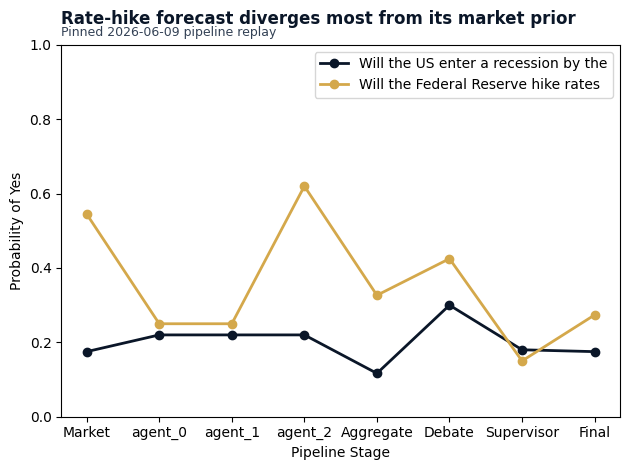

In [25]:
fig, ax = plt.subplots()
phase_order = flow_df["phase"].unique(maintain_order=True).to_list()
for i, (question_text, group) in enumerate(flow_df.group_by("question", maintain_order=True)):
    group = group.with_columns(pl.col("phase").cast(pl.Enum(phase_order))).sort("phase")
    ax.plot(
        group["phase"].to_list(),
        group["p_yes"].to_list(),
        marker="o",
        linewidth=2,
        color=[COLORS["blue"], COLORS["amber"]][i],
        label=question_text[0],
    )
ax.set_xlabel("Pipeline Stage")
ax.set_ylabel("Probability of Yes")
ax.set_ylim(0, 1)
add_message_title(
    ax,
    f"{farthest_question} forecast diverges most from its market prior",
    subtitle="Pinned 2026-06-09 pipeline replay",
)
ax.legend(loc="best")
fig.tight_layout()
fig.show()
plt.show()

## Token use

In [26]:
print(f"  Questions forecasted: {len(results)}")
print(f"  Total tokens: {grand_total.total_tokens:,}")
print(f"  Input tokens: {grand_total.input_tokens:,}")
print(f"  Output tokens: {grand_total.output_tokens:,}")

  Questions forecasted: 2
  Total tokens: 164,463
  Input tokens: 157,016
  Output tokens: 7,447


## State Persistence

Each forecast result can be serialized for replay and evaluation in NB09.

In [27]:
serialized = []
for r in results:
    entry = {
        "question": r.question.question,
        "cutoff_date": r.question.cutoff_date,
        "final_probability": r.final_probability,
        "resolved_outcome": r.question.resolved_outcome,
        "agent_probs": [a.p_yes for a in r.agents],
        "aggregate": r.aggregation.extremized_probability if r.aggregation else None,
        "debate_consensus": r.debate.consensus_reached if r.debate else None,
        "supervisor_p_yes": r.supervisor.p_yes if r.supervisor else None,
        "supervisor_confidence": r.supervisor.confidence if r.supervisor else None,
        "tokens": r.total_token_usage.total_tokens,
        "duration_s": r.duration_seconds,
    }
    serialized.append(entry)

print("Serialized results (for NB09 evaluation):")
print(json.dumps(serialized, indent=2))

Serialized results (for NB09 evaluation):
[
  {
    "question": "Will the US enter a recession by the end of 2026?",
    "cutoff_date": "",
    "final_probability": 0.175,
    "resolved_outcome": null,
    "agent_probs": [
      0.22,
      0.22,
      0.22
    ],
    "aggregate": 0.1166,
    "debate_consensus": false,
    "supervisor_p_yes": 0.18,
    "supervisor_confidence": "medium",
    "tokens": 82814,
    "duration_s": null
  },
  {
    "question": "Will the Federal Reserve hike rates in 2026?",
    "cutoff_date": "",
    "final_probability": 0.2737,
    "resolved_outcome": null,
    "agent_probs": [
      0.25,
      0.25,
      0.62
    ],
    "aggregate": 0.3266,
    "debate_consensus": false,
    "supervisor_p_yes": 0.15,
    "supervisor_confidence": "medium",
    "tokens": 81649,
    "duration_s": null
  }
]


**Interpretation**: The pipeline produces probability estimates by progressively
refining through four phases. Each phase adds information: agents provide
diverse evidence, aggregation weights by independence, debate stress-tests
the consensus, and the supervisor catches disagreements. With live questions,
these are genuine forecasts on unresolved events, not recall of known
outcomes.

The next cell computes the replay-specific interpretation from the pinned
artifacts. Provider prices are not part of the traces, so the notebook reports
token use rather than attaching a stale dollar estimate.

In [28]:
recession, rate_hike = results
display(
    Markdown(
        "**Replay result.** "
        f"The recession forecast ends at {recession.final_probability:.0%} "
        f"against a {recession.question.current_market_price:.0%} market prior. "
        f"The rate-hike forecast ends at {rate_hike.final_probability:.0%} "
        f"against {rate_hike.question.current_market_price:.0%}, a "
        f"{abs(rate_hike.final_probability - rate_hike.question.current_market_price):.0%} "
        "gap. This is disagreement, not evidence of accuracy. NB09 scores "
        "resolved forecasts with Brier and log loss."
    )
)

**Replay result.** The recession forecast ends at 18% against a 18% market prior. The rate-hike forecast ends at 27% against 55%, a 27% gap. This is disagreement, not evidence of accuracy. NB09 scores resolved forecasts with Brier and log loss.

## Key Takeaways

1. **Four-phase pipeline**: agents → aggregation → debate → supervisor
   progressively refines probability estimates
2. **Supervisor role**: detects disagreements, runs clarifying searches, and
   only overrides with high confidence, preserving agent diversity
3. **Confidence-gated override**: the supervisor's probability only replaces
   the ensemble when confidence is "high"
4. **Token cost scales linearly** with questions and agents
5. **State persistence** enables replay with different parameters and systematic
   evaluation (NB09)

**Next**: [`09_evaluation_and_governance`](09_evaluation_and_governance.ipynb) scores these forecasts, builds
calibration curves, run ablations, and implement security controls.

**Book**: Sections 24.7-24.8 cover the complete pipeline architecture and
production deployment considerations.